# Zero-Shot Concept Extraction on Chest X-rays (CheXpert)

Train-free pipeline: we never fit on labels. The "classifier" is a set of
positive/negative text prompts scored against image embeddings via cosine
similarity. Labels from `valid.csv` are used **only** to compute AUROC.

**Pipeline**
1. Preprocess images + build evaluation label matrix (no training)
2. Build concept vocabulary and prompt pairs
3. Embed images and prompts with a medical CLIP model (BiomedCLIP)
4. Score every image x concept via softmax over the pos/neg pair
5. Evaluate with per-concept AUROC + subgroup / prompt-sensitivity analysis

Data: `data/01_raw/chexpert/` (CheXpert-v1.0-small). `valid.csv` is fully
expert-annotated (no uncertain labels), so it is our clean eval set.


## 0. Config

Paths are resolved relative to the repo root so the notebook runs whether you
launch Jupyter from `notebooks/` or the project root.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import roc_auc_score

SEED = 0
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)


def find_repo_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "data" / "01_raw" / "chexpert").exists():
            return p
    raise FileNotFoundError("Could not locate data/01_raw/chexpert")


ROOT = find_repo_root()
RAW = ROOT / "data" / "01_raw" / "chexpert"
PROCESSED = ROOT / "data" / "03_primary"
EMB_DIR = ROOT / "data" / "06_models"
PROCESSED.mkdir(parents=True, exist_ok=True)
EMB_DIR.mkdir(parents=True, exist_ok=True)

# Concept vocabulary aligned to CheXpert labels (no manual annotation needed).
ALL_CONCEPTS = [
    "Cardiomegaly", "Pleural Effusion", "Edema", "Consolidation",
    "Atelectasis", "Pneumonia", "Pneumothorax", "Lung Opacity",
    "Enlarged Cardiomediastinum", "Support Devices", "Fracture", "Lung Lesion",
]
MIN_PREVALENCE = 0.05  # drop concepts with too few positives for a stable AUROC
print("ROOT:", ROOT)


device: mps
ROOT: /Users/Hirujan/Documents/GitHub/CLIP-zero-shot-concept-extraction-on-chest-X-rays


## 1. Load data and remap image paths

`Path` in the CSV is prefixed with `CheXpert-v1.0-small/`, which does not exist
on disk. Keep **frontal** views only, since the prompts describe a "chest X-ray"
(frontal AP/PA); laterals are a different distribution.

In [2]:
df = pd.read_csv(RAW / "valid.csv")
df["image_path"] = df["Path"].str.replace("CheXpert-v1.0-small/", "", regex=False)
df["image_path"] = df["image_path"].map(lambda p: RAW / p)
assert df["image_path"].map(Path.exists).all(), "some image paths are missing"

df = df[df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
print("frontal eval images:", len(df))
df[["Path", "image_path", "Sex", "Age", "AP/PA"]].head()


frontal eval images: 202


,Path,image_path,Sex,Age,AP/PA
0,CheXpert-v1.0-small/valid/patient64541/study1/...,/Users/Hirujan/Documents/GitHub/CLIP-zero-shot...,Male,73,AP
1,CheXpert-v1.0-small/valid/patient64542/study1/...,/Users/Hirujan/Documents/GitHub/CLIP-zero-shot...,Male,70,PA
2,CheXpert-v1.0-small/valid/patient64543/study1/...,/Users/Hirujan/Documents/GitHub/CLIP-zero-shot...,Male,85,AP
3,CheXpert-v1.0-small/valid/patient64544/study1/...,/Users/Hirujan/Documents/GitHub/CLIP-zero-shot...,Female,42,AP
4,CheXpert-v1.0-small/valid/patient64545/study1/...,/Users/Hirujan/Documents/GitHub/CLIP-zero-shot...,Female,55,AP


## 2. Evaluation labels (no training)

`valid.csv` has only `0.0 / 1.0` — no `-1.0` uncertain, no NaN. So there is no
label policy to resolve here; we just build the binary matrix for AUROC.

`train.csv` would need a U-Ones/U-Zeros policy only if you used it as *extra
eval* data (it is 72.8% NaN). We do not train on it.

In [3]:
Y = df[ALL_CONCEPTS].astype(float).copy()
assert not Y.isna().any().any(), "valid.csv should be fully labelled"

prevalence = Y.mean().sort_values(ascending=False)
concepts = prevalence[prevalence >= MIN_PREVALENCE].index.tolist()
excluded = prevalence[prevalence < MIN_PREVALENCE].index.tolist()

print(prevalence.round(3).to_string())
print("\nkept concepts:", concepts)
print("excluded (too few positives -> AUROC unstable):", excluded)
Y = Y[concepts]


Lung Opacity                  0.579
Enlarged Cardiomediastinum    0.520
Support Devices               0.490
Atelectasis                   0.371
Cardiomegaly                  0.327
Pleural Effusion              0.317
Edema                         0.208
Consolidation                 0.158
Pneumonia                     0.040
Pneumothorax                  0.035
Lung Lesion                   0.005
Fracture                      0.000

kept concepts: ['Lung Opacity', 'Enlarged Cardiomediastinum', 'Support Devices', 'Atelectasis', 'Cardiomegaly', 'Pleural Effusion', 'Edema', 'Consolidation']
excluded (too few positives -> AUROC unstable): ['Pneumonia', 'Pneumothorax', 'Lung Lesion', 'Fracture']


## 3. Metadata for subgroup analysis

Kept aside (never fed to the model) so we can check whether zero-shot
performance varies by sex or acquisition type (`AP/PA`).

In [4]:
meta = df[["Sex", "Age", "AP/PA"]].copy()
meta["age_bin"] = pd.cut(
    meta["Age"], bins=[0, 40, 60, 80, 120], labels=["<40", "40-59", "60-79", "80+"]
)
meta.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,202,2,Male,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,202.0,NaN,NaN,NaN,60.816832,18.336303,18.0,48.25,62.5,74.75,90.0
AP/PA,202,2,AP,169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_bin,202,4,60-79,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Load the vision-language model

We use **BiomedCLIP** (Microsoft) via `open_clip`; it is trained on medical
image-text pairs and should substantially beat generic CLIP on X-rays.

Swap `MODEL_NAME` for a generic model (e.g. `"ViT-B-32"` / `openai`) to run the
comparison and report the domain gap. Always use the model's own `preprocess`;
never hand-roll resize/normalize.

In [5]:
import open_clip

MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
# generic baseline for comparison:
# MODEL_NAME = "ViT-B-32"   # then pass pretrained="openai"

model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model = model.to(DEVICE).eval()
logit_scale = model.logit_scale.exp().detach().cpu()
print("loaded:", MODEL_NAME, "| logit_scale:", float(logit_scale))


loaded: hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 | logit_scale: 85.2322769165039


## 5. Build positive/negative prompt pairs

Several phrasings per concept. Prompt sensitivity is itself a finding, so we
keep every template and can score per-template later.

In [6]:
POSITIVE_PHRASES = {
    "Cardiomegaly": "cardiomegaly",
    "Pleural Effusion": "pleural effusion",
    "Edema": "pulmonary edema",
    "Consolidation": "consolidation",
    "Atelectasis": "atelectasis",
    "Pneumonia": "pneumonia",
    "Pneumothorax": "pneumothorax",
    "Lung Opacity": "lung opacity",
    "Enlarged Cardiomediastinum": "an enlarged cardiomediastinum",
    "Support Devices": "support devices",
    "Fracture": "a fracture",
    "Lung Lesion": "a lung lesion",
}

PROMPT_TEMPLATES = [
    "a chest X-ray with {}.",
    "a chest radiograph showing {}.",
    "the chest X-ray demonstrates {}.",
    "a frontal chest X-ray with {}.",
]

records = []
for c in concepts:
    pos_phrase = POSITIVE_PHRASES[c]
    neg_phrase = "no " + pos_phrase
    for t in PROMPT_TEMPLATES:
        records.append((c, "pos", t.format(pos_phrase)))
        records.append((c, "neg", t.format(neg_phrase)))

prompts = pd.DataFrame(records, columns=["concept", "polarity", "prompt"])
prompts["prompt_id"] = np.arange(len(prompts))
print(prompts.groupby(["concept", "polarity"]).size().unstack().head())
prompts.head(8)


polarity                    neg  pos
concept                             
Atelectasis                   4    4
Cardiomegaly                  4    4
Consolidation                 4    4
Edema                         4    4
Enlarged Cardiomediastinum    4    4


,concept,polarity,prompt,prompt_id
0,Lung Opacity,pos,a chest X-ray with lung opacity.,0
1,Lung Opacity,neg,a chest X-ray with no lung opacity.,1
2,Lung Opacity,pos,a chest radiograph showing lung opacity.,2
3,Lung Opacity,neg,a chest radiograph showing no lung opacity.,3
4,Lung Opacity,pos,the chest X-ray demonstrates lung opacity.,4
5,Lung Opacity,neg,the chest X-ray demonstrates no lung opacity.,5
6,Lung Opacity,pos,a frontal chest X-ray with lung opacity.,6
7,Lung Opacity,neg,a frontal chest X-ray with no lung opacity.,7


## 6. Embed prompts

Normalised text embeddings. For each concept we later average the positive
templates and the negative templates separately.

In [7]:
with torch.no_grad():
    tokens = tokenizer(prompts["prompt"].tolist())
    text_emb = model.encode_text(tokens.to(DEVICE))
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    text_emb = text_emb.cpu().numpy()

print("text embedding matrix:", text_emb.shape)


text embedding matrix: (64, 512)


## 7. Embed images (and cache)

Images are decoded to RGB (X-rays are 1-channel) and transformed exactly once by
the model's `preprocess`. Embeddings are cached to disk so prompt iteration does
not re-run the image encoder.

In [8]:
from torch.utils.data import DataLoader, Dataset


class CheXpertImages(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img)


cache_path = EMB_DIR / "valid_image_embeddings.npy"
if cache_path.exists():
    image_emb = np.load(cache_path)
    print("loaded cached embeddings:", image_emb.shape)
else:
    ds = CheXpertImages(df["image_path"], preprocess)
    dl = DataLoader(ds, batch_size=32, num_workers=0)  # 0 avoids macOS spawn issues in notebooks
    chunks = []
    with torch.no_grad():
        for batch in dl:
            e = model.encode_image(batch.to(DEVICE))
            e = e / e.norm(dim=-1, keepdim=True)
            chunks.append(e.cpu().numpy())
    image_emb = np.concatenate(chunks, axis=0)
    np.save(cache_path, image_emb)
    print("computed and cached embeddings:", image_emb.shape)

assert image_emb.shape[0] == len(df)


loaded cached embeddings: (202, 512)


## 8. Alignment sanity checks

Images, labels, and embeddings must stay index-aligned. Verify before scoring.

In [9]:
assert len(df) == len(Y) == len(image_emb), "row count mismatch"
assert Y.index.equals(df.index), "label/image index misaligned"
assert image_emb.shape[0] == len(Y), "embedding/label count mismatch"

print("all checks passed")
print("images:", image_emb.shape, "| concepts:", list(Y.columns))


all checks passed
images: (202, 512) | concepts: ['Lung Opacity', 'Enlarged Cardiomediastinum', 'Support Devices', 'Atelectasis', 'Cardiomegaly', 'Pleural Effusion', 'Edema', 'Consolidation']


## 9. Zero-shot scores: image x concept matrix

For each concept: average positive and negative prompt embeddings, compute
cosine similarities, then softmax over the pos/neg pair (scaled by the model's
learned `logit_scale`). This yields a probability-like score per image/concept.

In [10]:
scores = pd.DataFrame(index=df.index)

with torch.no_grad():
    for c in concepts:
        sub = prompts[prompts["concept"] == c]
        pos_ids = sub.loc[sub["polarity"] == "pos", "prompt_id"].values
        neg_ids = sub.loc[sub["polarity"] == "neg", "prompt_id"].values
        pos = text_emb[pos_ids].mean(axis=0)
        neg = text_emb[neg_ids].mean(axis=0)
        pos /= np.linalg.norm(pos)
        neg /= np.linalg.norm(neg)

        logits = np.stack([image_emb @ pos, image_emb @ neg], axis=1)
        logits = torch.tensor(logits) * logit_scale
        scores[c] = torch.softmax(logits, dim=1)[:, 0].numpy()

scores.describe().T


,count,mean,std,min,25%,50%,75%,max
Lung Opacity,202.0,0.425533,0.361355,0.003659,0.064965,0.313226,0.814355,0.999913
Enlarged Cardiomediastinum,202.0,0.173311,0.236874,0.000137,0.008097,0.061346,0.226479,0.962647
Support Devices,202.0,0.250519,0.312834,0.000027,0.009454,0.086854,0.370459,0.998143
Atelectasis,202.0,0.230659,0.240443,0.009667,0.056107,0.138672,0.311052,0.994283
Cardiomegaly,202.0,0.105768,0.221595,0.000009,0.001010,0.007908,0.078546,0.996691
Pleural Effusion,202.0,0.127709,0.247134,0.000012,0.001042,0.011448,0.095746,0.999795
Edema,202.0,0.289775,0.344913,0.000499,0.017105,0.106139,0.522976,0.999715
Consolidation,202.0,0.187842,0.296827,0.000105,0.004578,0.028030,0.231094,0.999669


In [11]:
scores.to_csv(PROCESSED / "valid_zero_shot_scores.csv")
Y.to_csv(PROCESSED / "valid_labels.csv")
meta.to_csv(PROCESSED / "valid_metadata.csv")
print("saved scores, labels, metadata")


saved scores, labels, metadata


## 10. Evaluate: per-concept AUROC

AUROC is the standard CheXpert-style metric and is threshold-free, so class
imbalance does not require special handling.

In [12]:
rows = []
for c in concepts:
    y = Y[c].values
    if y.min() == y.max():
        rows.append({"concept": c, "auroc": np.nan, "prevalence": float(y.mean())})
    else:
        rows.append({
            "concept": c,
            "auroc": roc_auc_score(y, scores[c].values),
            "prevalence": float(y.mean()),
        })
auroc = pd.DataFrame(rows).sort_values("auroc", ascending=False).reset_index(drop=True)
auroc


,concept,auroc,prevalence
0,Edema,0.845685,0.207921
1,Enlarged Cardiomediastinum,0.820815,0.519802
2,Pleural Effusion,0.818048,0.316832
3,Consolidation,0.806434,0.158416
4,Lung Opacity,0.777577,0.579208
5,Cardiomegaly,0.770053,0.326733
6,Support Devices,0.689124,0.490099
7,Atelectasis,0.599265,0.371287


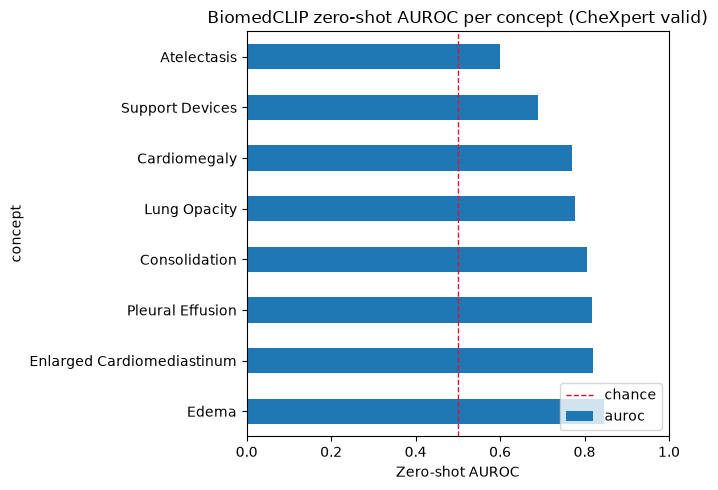

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
auroc.plot.barh(x="concept", y="auroc", ax=ax, legend=False)
ax.axvline(0.5, color="crimson", ls="--", lw=1, label="chance")
ax.set_xlim(0, 1)
ax.set_xlabel("Zero-shot AUROC")
ax.set_title("BiomedCLIP zero-shot AUROC per concept (CheXpert valid)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROOT / "data" / "08_reporting" / "auroc_per_concept.png", dpi=150)
plt.show()


## 11. Failure modes: subgroup analysis

Does zero-shot performance differ by sex or acquisition type (`AP/PA`)?


In [14]:
def subgroup_auroc(concept, group_col):
    out = []
    for g, idx in df.groupby(group_col).groups.items():
        y = Y.loc[idx, concept].values
        if y.min() == y.max():
            continue
        out.append({
            "group": g,
            "n": len(idx),
            "auroc": roc_auc_score(y, scores.loc[idx, concept].values),
        })
    return pd.DataFrame(out)


for concept in concepts[:4]:
    print(f"\n=== {concept} by Sex ===")
    print(subgroup_auroc(concept, "Sex").round(3).to_string(index=False))



=== Lung Opacity by Sex ===
 group   n  auroc
Female  94  0.807
  Male 108  0.759

=== Enlarged Cardiomediastinum by Sex ===
 group   n  auroc
Female  94  0.767
  Male 108  0.860

=== Support Devices by Sex ===
 group   n  auroc
Female  94  0.660
  Male 108  0.706

=== Atelectasis by Sex ===
 group   n  auroc
Female  94  0.634
  Male 108  0.571


## 12. Prompt sensitivity

Re-score using one template at a time to see how much AUROC moves with phrasing.

In [15]:
def scores_for_template(t_idx):
    out = pd.DataFrame(index=df.index)
    with torch.no_grad():
        for c in concepts:
            sub = prompts[prompts["concept"] == c]
            pos_ids = sub.loc[sub["polarity"] == "pos", "prompt_id"].values
            neg_ids = sub.loc[sub["polarity"] == "neg", "prompt_id"].values
            pos = text_emb[pos_ids[t_idx]]
            neg = text_emb[neg_ids[t_idx]]
            logits = torch.tensor(np.stack([image_emb @ pos, image_emb @ neg], axis=1)) * logit_scale
            out[c] = torch.softmax(logits, dim=1)[:, 0].numpy()
    return out


sensitivity = pd.DataFrame(
    {
        t: {c: roc_auc_score(Y[c].values, scores_for_template(i)[c].values) for c in concepts}
        for i, t in enumerate(PROMPT_TEMPLATES)
    }
)
sensitivity.round(3)


,a chest X-ray with {}.,a chest radiograph showing {}.,the chest X-ray demonstrates {}.,a frontal chest X-ray with {}.
Lung Opacity,0.767,0.781,0.790,0.760
Enlarged Cardiomediastinum,0.817,0.815,0.824,0.818
Support Devices,0.689,0.688,0.681,0.688
Atelectasis,0.606,0.582,0.554,0.636
Cardiomegaly,0.772,0.764,0.776,0.767
Pleural Effusion,0.816,0.818,0.815,0.819
Edema,0.847,0.846,0.853,0.836
Consolidation,0.792,0.810,0.813,0.796


## 13. Write-up notes

Record for the report:
- Model + prompt templates used, and the U-policy (not applicable here).
- Per-concept AUROC table and prevalence (context for rare concepts).
- Excluded concepts and why (insufficient positives).
- Subgroup deltas (sex, AP/PA) and prompt-sensitivity range.
- Framing: concept proxies are validated against labels, **not** causal or
  explicitly annotated concepts.
